# 🕵️‍♂️ Global Syndicate Taskforce: RL Training Loop

**Training a model to overcome 'Collective Delusion' using OpenEnv, TRL (GRPO), and Unsloth.**

This notebook represents the core pipeline of our project. Current LLMs suffer from 'sycophancy'—if another agent tells them something, they believe it. In our Anti-Money Laundering environment, an LLM must learn to stop trusting hallucinating Tier 1 Analysts, interrogate Bank Liaisons with correct policy mandates, and construct an airtight evidence chain for the Legal Officer.

### 🏆 Our Stack:
- **Environment:** OpenEnv (FastAPI)
- **Base Model:** `unsloth/Qwen2.5-3B-Instruct`
- **RL Framework:** TRL (GRPO - Group Relative Policy Optimization)
- **Compiler:** Unsloth (for extremely fast, memory-efficient LoRA adapters)

## ⚙️ 1. Local Jupyter / Mac Setup
This notebook is now configured for **local Jupyter on Mac** (no Colab required).

It assumes you are running from the repository root. We install the minimal dependencies for the Mac training path (`train_grpo_mac.py`) and plotting artifacts for submission.

In [1]:
from pathlib import Path
import os

# Auto-detect repository root from current directory or its parents
cwd = Path.cwd().resolve()
candidates = [cwd] + list(cwd.parents)
project_root = None
for p in candidates:
    if (p / "server").exists() and (p / "train_grpo_mac.py").exists() and (p / "pyproject.toml").exists():
        project_root = p
        break

if project_root is None:
    raise FileNotFoundError("Could not locate project root. Open notebook inside the project tree.")

os.chdir(project_root)
print(f"Using project root: {project_root}")

# Local Jupyter dependency install (Mac-friendly)
%pip install -q -U pip
%pip install -q torch transformers datasets trl peft requests openenv-core fastapi uvicorn matplotlib

print("✅ Environment setup complete.")

Using project root: /Users/md.kamranalam/Programming/hackathon/global_syndicate_taskforce_env
/Users/md.kamranalam/Programming/hackathon/global_syndicate_taskforce_env/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/Users/md.kamranalam/Programming/hackathon/global_syndicate_taskforce_env/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
✅ Environment setup complete.


## 🌍 2. Booting the OpenEnv API Server
The environment is decoupled from training and exposed through FastAPI.

This cell starts `uvicorn` in the current Jupyter session and verifies `/health` so we know training can interact with the environment.

In [2]:
import subprocess
import time
import requests
import sys

# Best effort cleanup of previous server
subprocess.run(["pkill", "-f", "uvicorn"], check=False)

print("Starting OpenEnv server...")
server_process = subprocess.Popen(
    [sys.executable, "-m", "uvicorn", "server.app:app", "--host", "0.0.0.0", "--port", "8000"]
)

time.sleep(4)

print("Testing /health endpoint...")
health = requests.get("http://127.0.0.1:8000/health", timeout=5)
print("Health status:", health.status_code)

print("Testing /step endpoint...")
step = requests.post(
    "http://127.0.0.1:8000/step",
    json={"action": {"target_actor": "Tier_1_Analyst", "operation": "fetch_triage_report"}},
    timeout=5,
)
print("Step status:", step.status_code)
print("Step response:", step.json())

assert health.status_code == 200 and step.status_code == 200, "Server failed smoke test"
print("✅ Server is ready for training.")


Starting OpenEnv server...


INFO:     Started server process [62942]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


Testing /health endpoint...
INFO:     127.0.0.1:58733 - "GET /health HTTP/1.1" 200 OK
Health status: 200
Testing /step endpoint...
INFO:     127.0.0.1:58734 - "POST /step HTTP/1.1" 200 OK
Step status: 200
Step response: {'observation': {'transaction_id': 'TX-1024', 'amount': 1200.0, 'verified_facts': [], 'system_alerts': 'Analyst Report: Transaction appears CLEAN_VERIFIED.'}, 'reward': -0.05, 'done': False}
✅ Server is ready for training.


## 🧠 3. Execute the GRPO Training Loop (Mac/Jupyter Path)
For local Mac testing, run the lightweight training script first (`train_grpo_mac.py`).

This gives you a reproducible baseline run, adapter artifacts, and trainer logs you can plot.

Once you have access to stronger GPU, run `train_grpo_unsloth.py` for full-scale training.

In [3]:
# Mac-safe baseline training
!python train_grpo_mac.py

Loading Tiny Model for Mac...
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|███████████████████████| 290/290 [00:01<00:00, 285.40it/s]
Starting GRPO Training on Mac...
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
  0%|                                                    | 0/20 [00:00<?, ?it/s]INFO:     127.0.0.1:58920 - "POST /step HTTP/1.1" 422 Unprocessable Content
INFO:     127.0.0.1:58921 - "POST /step HTTP/1.1" 422 Unprocessable Content
{'loss': '-0.3328', 'grad_norm': '0.3514', 'learning_rate': '5e-05', 'num_tokens': '243', 'completions/mean_length': '43.5', 'completions/min_length': '41', 'completions/max_length': '46', 'completions/clipped_ratio': '0', 'completions/mean_terminated_length': '43.5', 'comp

## 📈 4. Generate Reward/Loss Plot Artifacts
This cell reads `trainer_state.json` from `outputs_mac/` and exports:
- `docs/reward_curve.png`
- `docs/loss_curve.png`

These are the exact artifacts you need for your hackathon README/submission.

Matplotlib is building the font cache; this may take a moment.


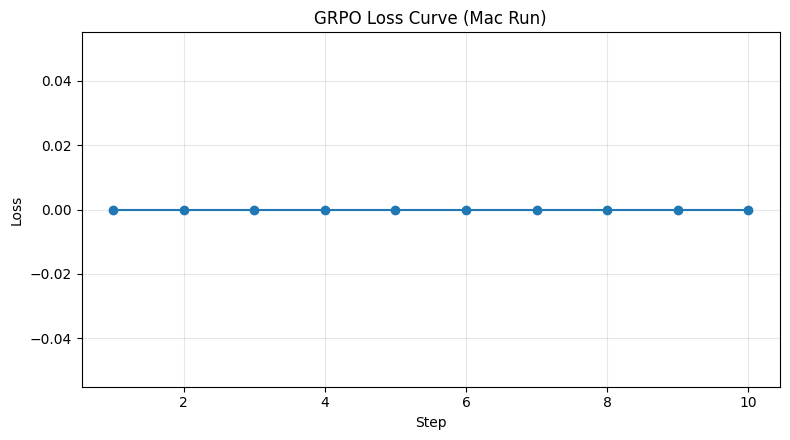

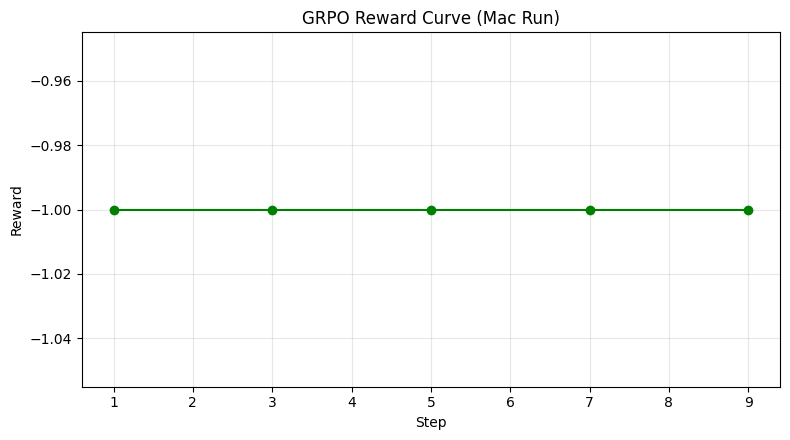

✅ Created adapter archive: /Users/md.kamranalam/Programming/hackathon/global_syndicate_taskforce_env/grpo_trained_auditor_mac.zip
✅ Plot artifacts ready: docs/reward_curve.png, docs/loss_curve.png


In [4]:
import json
import shutil
from pathlib import Path
import matplotlib.pyplot as plt

state_file = Path("outputs_mac/checkpoint-10/trainer_state.json")
if not state_file.exists():
    checkpoints = sorted(Path("outputs_mac").glob("checkpoint-*/trainer_state.json"))
    if not checkpoints:
        raise FileNotFoundError("No trainer_state.json found in outputs_mac.")
    state_file = checkpoints[-1]

state = json.loads(state_file.read_text())
log_history = state.get("log_history", [])

steps, losses = [], []
reward_steps, rewards = [], []

for row in log_history:
    step = row.get("step")
    if step is None:
        continue
    if row.get("loss") is not None:
        steps.append(step)
        losses.append(float(row["loss"]))
    if row.get("reward") is not None:
        reward_steps.append(step)
        rewards.append(float(row["reward"]))

Path("docs").mkdir(exist_ok=True)

plt.figure(figsize=(8, 4.5))
plt.plot(steps, losses, marker="o")
plt.title("GRPO Loss Curve (Mac Run)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("docs/loss_curve.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(reward_steps, rewards, marker="o", color="green")
plt.title("GRPO Reward Curve (Mac Run)")
plt.xlabel("Step")
plt.ylabel("Reward")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("docs/reward_curve.png", dpi=180)
plt.show()

# Zip trained adapters for portability
if Path("grpo_trained_auditor_mac").exists():
    zip_path = shutil.make_archive("grpo_trained_auditor_mac", "zip", "grpo_trained_auditor_mac")
    print(f"✅ Created adapter archive: {zip_path}")
else:
    print("⚠️ Adapter folder grpo_trained_auditor_mac not found yet.")

print("✅ Plot artifacts ready: docs/reward_curve.png, docs/loss_curve.png")

## 🚀 5. Optional Full GPU Run (When Available)
If you get access to stronger GPU later, run the upgraded Unsloth pipeline:

`python train_grpo_unsloth.py --max-steps 120 --output-dir grpo_trained_auditor --plot-dir docs`

This will train with the larger model path and auto-generate submission plots.

In [6]:
# Optional GPU-scale training command
!python train_grpo_unsloth.py --max-steps 120 --output-dir grpo_trained_auditor --plot-dir docs

Traceback (most recent call last):
  File "/Users/md.kamranalam/Programming/hackathon/global_syndicate_taskforce_env/train_grpo_unsloth.py", line 13, in <module>
    from unsloth import FastLanguageModel
ModuleNotFoundError: No module named 'unsloth'
